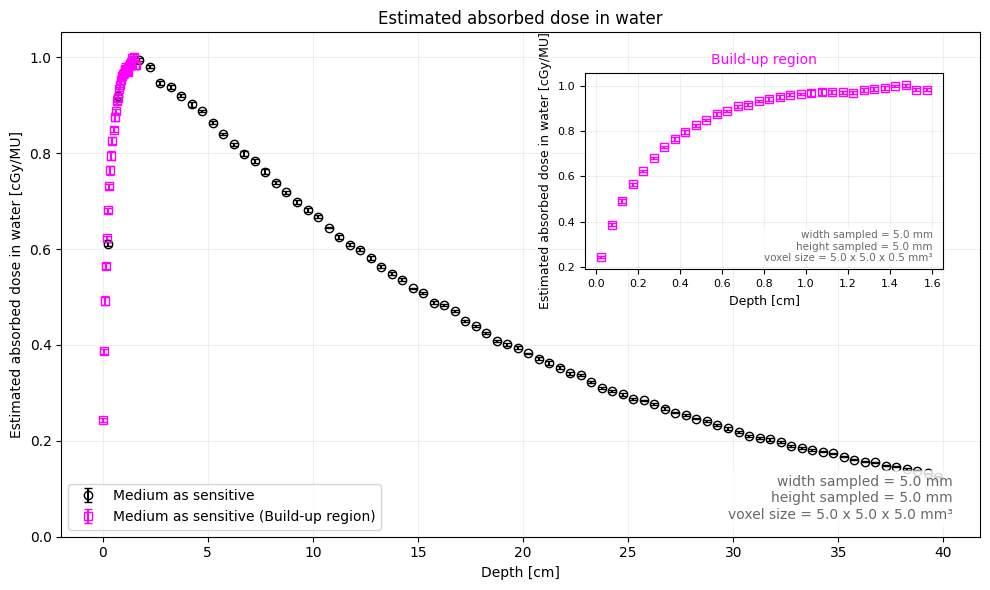

Counts:
Original points PDD      : 80
Depth range PDD [cm]     : 0.250 to 39.750
Original points buildup  : 32
Depth range buildup [cm] : 0.025 to 1.575
Dmax depth [cm]          : 1.750
Dmax mean dose [cGy/MU]     : 0.994673


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REQUIRED_COLS = ["iZ", "depth_mm", "mean_dose_cGy", "err_dose_cGy"]
MAIN_COLOR = "black"
BUILDUP_COLOR = "magenta"

DATA_DIR_CANDIDATES = [
    Path.cwd() / "data",
    Path.cwd() / "pdd" / "data",
    Path.cwd() / "analysis" / "dosimetry_invivo" / "pdd" / "data",
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the data directory. Run the notebook from analysis/dosimetry_invivo/pdd, analysis/dosimetry_invivo, or the repository root."
    )

DEPTH_ORIGIN_CM = 49.75
DEPTH_STEP_CM = 0.5


def load_profile(csv_name):
    df = pd.read_csv(DATA_DIR / csv_name)
    for col in REQUIRED_COLS:
        assert col in df.columns, f"Missing required column in {csv_name}: {col}"
    assert len(df) >= 5
    assert df["iZ"].is_monotonic_increasing
    assert np.allclose(np.diff(df["iZ"].to_numpy()), 1.0)
    return df


_df = load_profile("pdd.csv")
_df_buildup = load_profile("pddBuildup_.csv")

# Use the voxel-center depth convention requested for the PDD axis.
_df["depth_cm"] = DEPTH_ORIGIN_CM - _df["iZ"] * DEPTH_STEP_CM
assert np.allclose(_df["depth_mm"].to_numpy(), 10.0 * _df["depth_cm"].to_numpy())
_df = _df.sort_values("depth_cm").reset_index(drop=True)
assert _df["depth_cm"].is_monotonic_increasing

# Use the scorer-generated depth for the buildup mesh.
_df_buildup["depth_cm"] = _df_buildup["depth_mm"] / 10.0
_df_buildup = _df_buildup.sort_values("depth_cm").reset_index(drop=True)
assert _df_buildup["depth_cm"].is_monotonic_increasing

x = _df["depth_cm"].to_numpy()
dose = _df["mean_dose_cGy"].to_numpy()
dose_err = _df["err_dose_cGy"].to_numpy()

x_buildup = _df_buildup["depth_cm"].to_numpy()
dose_buildup = _df_buildup["mean_dose_cGy"].to_numpy()
dose_err_buildup = _df_buildup["err_dose_cGy"].to_numpy()

dmax_idx = int(np.argmax(dose))
dmax_cm = float(x[dmax_idx])
dose_max = float(dose[dmax_idx])
assert dose_max > 0.0

y = dose
yerr = dose_err
y_buildup = dose_buildup
yerr_buildup = dose_err_buildup

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    capsize=3,
    color=MAIN_COLOR,
    ecolor=MAIN_COLOR,
    mfc="none",
    mec=MAIN_COLOR,
    label="Medium as sensitive",
)
ax.errorbar(
    x_buildup,
    y_buildup,
    yerr=yerr_buildup,
    fmt="s",
    capsize=3,
    color=BUILDUP_COLOR,
    ecolor=BUILDUP_COLOR,
    mfc="none",
    mec=BUILDUP_COLOR,
    label="Medium as sensitive (Build-up region)",
)
ax.set_xlabel("Depth [cm]")
ax.set_ylabel("Estimated absorbed dose in water [cGy/MU]")
ax.set_title("Estimated absorbed dose in water")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.2)

sampled_text = "\n".join([
    "width sampled = 5.0 mm",
    "height sampled = 5.0 mm",
    "voxel size = 5.0 x 5.0 x 5.0 mm³",
])
ax.text(
    0.97,
    0.03,
    sampled_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="dimgray",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, boxstyle="round,pad=0.35"),
)

ax_zoom = ax.inset_axes([0.57, 0.53, 0.39, 0.39])
ax_zoom.errorbar(
    x_buildup,
    y_buildup,
    yerr=yerr_buildup,
    fmt="s",
    capsize=3,
    color=BUILDUP_COLOR,
    ecolor=BUILDUP_COLOR,
    mfc="none",
    mec=BUILDUP_COLOR,
)
ax_zoom.set_title("Build-up region", fontsize=10, color=BUILDUP_COLOR)
ax_zoom.set_xlabel("Depth [cm]", fontsize=9)
ax_zoom.set_ylabel("Estimated absorbed dose in water [cGy/MU]", fontsize=9)
ax_zoom.grid(True, alpha=0.2)
ax_zoom.tick_params(axis="both", labelsize=8)
ax_zoom.set_facecolor("white")
buildup_text = "\n".join([
    "width sampled = 5.0 mm",
    "height sampled = 5.0 mm",
    "voxel size = 5.0 x 5.0 x 0.5 mm³",
])
ax_zoom.text(
    0.97,
    0.03,
    buildup_text,
    transform=ax_zoom.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="dimgray",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, boxstyle="round,pad=0.3"),
)
for spine in ax_zoom.spines.values():
    spine.set_edgecolor("black")

x_span_buildup = float(x_buildup.max() - x_buildup.min())
x_pad = 0.05 * max(1.0, x_span_buildup)
zoom_ymin = max(0.0, float(np.min(y_buildup - yerr_buildup)) - 0.05)
zoom_ymax = float(np.max(y_buildup + yerr_buildup)) + 0.05
ax_zoom.set_xlim(float(x_buildup.min()) - x_pad, float(x_buildup.max()) + x_pad)
ax_zoom.set_ylim(zoom_ymin, zoom_ymax)

ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("Counts:")
print("Original points PDD      :", len(x))
print("Depth range PDD [cm]     :", f"{x.min():.3f} to {x.max():.3f}")
print("Original points buildup  :", len(x_buildup))
print("Depth range buildup [cm] :", f"{x_buildup.min():.3f} to {x_buildup.max():.3f}")
print("Dmax depth [cm]          :", f"{dmax_cm:.3f}")
print("Dmax mean dose [cGy/MU]     :", f"{dose_max:.6f}")
